# ACP sur le reseau eectrique de la Senelec

## Importation des Packages et des donnees de la Senelec

In [34]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [17]:
chemin = r'F:\Mes_Documents_de_these\DOCUMENTS_RECHERCHE\DOCUMENTS_DE_REPPORTS\Projets_Articles_These\Projet_ArticleN01\Exploration_des_Donnees\Demande_2019.xlsx'
Donnees = pd.read_excel(chemin)
Donnees.head()

,DateHeure,Heure,Puis. Dispo,Puis TAG couplée,Demande,Fréq
0,2019-01-01 00:00:00,1,636.930263,0.0,430.407707,50.109
1,2019-01-01 01:00:00,2,636.930263,0.0,406.129563,49.939
2,2019-01-01 02:00:00,3,636.930263,0.0,372.603857,50.281
3,2019-01-01 03:00:00,4,636.930263,0.0,356.614000,50.365
4,2019-01-01 04:00:00,5,636.930263,0.0,352.424888,50.199


In [18]:
Donnees.shape

(837, 6)

In [19]:
chemin2  = r'F:\Mes_Documents_de_these\DOCUMENTS_RECHERCHE\DOCUMENTS_DE_REPPORTS\Projets_Articles_These\Projet_ArticleN01\Exploration_des_Donnees\Delestage_janvier2019.xlsx'
delestage = pd.read_excel(chemin2)
delestage.head()

,Heure,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence
0,1 h,636.930263,430.407707,0,0.0,0.0,0.0,50.109
1,2 h,636.930263,406.129563,0,0.0,0.0,0.0,49.939
2,3 h,636.930263,372.603857,0,0.0,0.0,0.0,50.281
3,4 h,636.930263,356.614000,0,0.0,3.3,3.3,50.365
4,5 h,636.930263,352.424888,0,0.0,0.0,0.0,50.199


In [20]:
delestage['PuissanceTAGcouplée'] = Donnees['Puis TAG couplée'].values

delestage.head()

,Heure,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence,PuissanceTAGcouplée
0,1 h,636.930263,430.407707,0,0.0,0.0,0.0,50.109,0.0
1,2 h,636.930263,406.129563,0,0.0,0.0,0.0,49.939,0.0
2,3 h,636.930263,372.603857,0,0.0,0.0,0.0,50.281,0.0
3,4 h,636.930263,356.614000,0,0.0,3.3,3.3,50.365,0.0
4,5 h,636.930263,352.424888,0,0.0,0.0,0.0,50.199,0.0


In [21]:
delestage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Heure                          837 non-null    object 
 1   P.dispo (MW)                   837 non-null    float64
 2   Demande (MW)                   837 non-null    float64
 3   Délest par Manque Product      837 non-null    int64  
 4   P. Effacée (MW)                837 non-null    float64
 5   Autres         P. coupée (MW)  837 non-null    float64
 6   Déficit total (MW)             837 non-null    float64
 7   Frequence                      837 non-null    float64
 8   PuissanceTAGcouplée            837 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 59.0+ KB


In [23]:
delestage.isnull().sum()

Heure                            0
P.dispo (MW)                     0
Demande (MW)                     0
Délest par Manque Product        0
P. Effacée (MW)                  0
Autres         P. coupée (MW)    0
Déficit total (MW)               0
Frequence                        0
PuissanceTAGcouplée              0
dtype: int64

In [33]:
delestage.describe()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence,PuissanceTAGcouplée
count,837.000000,837.000000,837.0,837.000000,837.000000,837.000000,837.000000,837.000000
mean,591.595115,420.599160,0.0,0.320789,1.012978,1.333767,50.127481,2.226404
std,56.563381,59.904779,0.0,1.427732,2.005418,2.447678,0.196881,6.887106
min,486.850000,284.344743,0.0,0.000000,0.000000,0.000000,49.593000,0.000000
25%,544.850000,375.751790,0.0,0.000000,0.000000,0.000000,50.038000,0.000000
50%,585.750000,412.925887,0.0,0.000000,0.050000,0.100000,50.114000,0.000000
75%,631.950000,467.139058,0.0,0.000000,1.200000,1.500000,50.281000,0.000000
max,733.988833,545.752726,0.0,8.000000,15.870000,15.870000,50.534000,42.000000


### Correlation entre les variable 

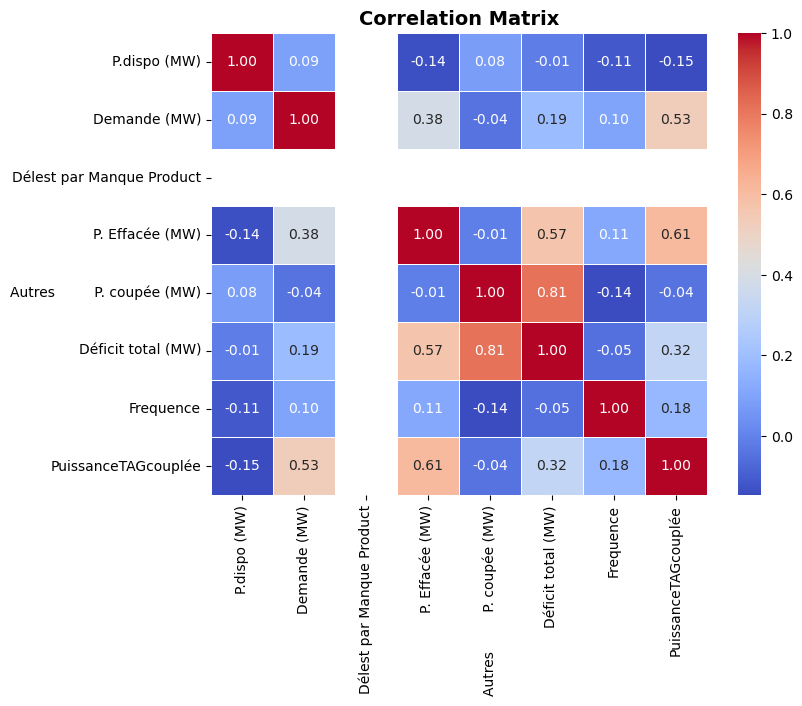

In [37]:
# Calcul de la matrice de corrélation
corr_matrix = delestage.drop('Heure',axis=1).corr()

# Création du heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Ajout d'un titre
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")

# Affichage
plt.show()

Cette figure reprente la correlation qui existe entre les variables. En generale toutes les corretations sont inferieurs
à 50% d'ou la non significativité de ces corrections. Cependant, celles de la puissance effacée avec la puissance TAG Couple,demande avec TAG et celles de deficit avec coupées et effacées respectivement de 80% et 55%. D'apres cette figure nous pour dire que le couplage de la puissance TAG dans le reseau est proportionnel a la demande et aux puissance effacées. Elle contribue à 18% sur les fluctuation de la frequence. En plus le deficit contribu à 81% coupure de puissances et à 57% des puissances effacées